In [2]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import matplotlib.pyplot as plt
import numpy as np

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from autoencoder import ConvAutoencoder
from solver import dev_train_vali_all_epochs_conv, test_conv
from rf_computation import compute_rf_for_single_model

In [ ]:
print(torch.cuda.is_available())
device = torch.device(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

True


In [3]:
save_path = '/home/david/paper_cifar_models/cnn/singular_step2/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

In [4]:
# CIFAR10 normalization (RGB channels)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR10 datasets
cifar_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
cifar_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split training set into train/validation
train_size = int(len(cifar_train) * 0.8)  # 40,000 samples
validation_size = len(cifar_train) - train_size  # 10,000 samples
cifar_train, cifar_val = torch.utils.data.random_split(cifar_train, [train_size, validation_size])

# Create data loaders
batch_size = 128
train_loader = DataLoader(cifar_train, batch_size=batch_size, shuffle=True, num_workers=6)
validation_loader = DataLoader(cifar_val, batch_size=batch_size, shuffle=False, num_workers=6)
test_loader = DataLoader(cifar_test, batch_size=batch_size, shuffle=False, num_workers=6)

Files already downloaded and verified
Files already downloaded and verified


In [5]:
dae_model = ConvAutoencoder(latent_dim=16)
dae_optimizer = torch.optim.SGD(dae_model.parameters(), lr=0.1, momentum=0.9)
print(dae_model)

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=1024, out_features=16, bias=True)
  )
  (linear): Sequential(
    (0): Linear(in_features=16, out_features=1024, bias=True)
    (1): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1

In [4]:
size_ls = (
	[1] * 5 + [2] * 5 + [3] * 5 + [4] * 5 + [5] * 5 + [6] * 5 + [7] * 5 + [8] * 5 + [9] * 5
	+ [10] * 5 + [11] * 5 + [12] * 5 + [13] * 5 + [14] * 5 + [15] * 5 + [16] * 5 
    + [17] * 5 + [18] * 5 + [19] * 5
	+ [20] * 5 + [21] * 5 + [22] * 5 + [23] * 5 + [24] * 5 + [25] * 5 + [26] * 5 + [27] * 5 + [28] * 5 + [29] * 5 
    + [30] * 5 + [31] * 5 + [32] * 5 + [33] * 5 + [34] * 5 + [35] * 5 + [36] * 5
	+ [37] * 5 + [38] * 5 + [39] * 5 + [40] * 5 + [41] * 5 + [42] * 5 + [43] * 5 + [44] * 5 + [45] * 5 + [46] * 5 
    + [47] * 5 + [48] * 5 + [49] * 5 + [50] * 5
	+ [51] * 5 + [52] * 5 + [53] * 5 + [54] * 5 + [55] * 5 + [56] * 5 + [57] * 5 + [58] * 5 + [59] * 5 + [60] * 5 
    + [61] * 5 + [62] * 5 + [63] * 5 + [64] * 5
	# + [65] * 5 + [66] * 5 + [67] * 5 + [68] * 5 + [69] * 5 + [70] * 5 + [71] * 5 + [72] * 5 + [73] * 5 + [74] * 5 
    # + [75] * 5 + [76] * 5 + [77] * 5 + [78] * 5 + [79] * 5
	# + [80] * 5 + [81] * 5 + [82] * 5 + [83] * 5 + [84] * 5 + [85] * 5 + [86] * 5 + [87] * 5 + [88] * 5 + [89] * 5 
    # + [90] * 5 + [91] * 5 + [92] * 5 + [93] * 5
	# + [94] * 5 + [95] * 5 + [96] * 5 + [97] * 5 + [98] * 5 + [99] * 5 + [100] * 5 + [101] * 5 + [102] * 5 
    # + [103] * 5 + [104] * 5 + [105] * 5 + [106] * 5
	# + [107] * 5 + [108] * 5 + [109] * 5 + [110] * 5 + [111] * 5 + [112] * 5 + [113] * 5 + [114] * 5 + [115] * 5 
    # + [116] * 5 + [117] * 5 + [118] * 5 + [119] * 5
	# + [120] * 5 + [121] * 5 + [122] * 5 + [123] * 5 + [124] * 5 + [125] * 5 + [126] * 5 + [127] * 5 + [128] * 5
)

In [7]:
train_loss,vali_loss = dev_train_vali_all_epochs_conv(
                                                            dae_model,
                                                            size_ls,
                                                            train_loader,
                                                            validation_loader,
                                                            dae_optimizer,
                                                            len(size_ls),
                                                            device,
                                                            save_path
                                                            )

[ 1  1  1  1  1  2  2  2  2  2  3  3  3  3  3  4  4  4  4  4  5  5  5  5
  5  6  6  6  6  6  7  7  7  7  7  8  8  8  8  8  9  9  9  9  9 10 10 10
 10 10 11 11 11 11 11 12 12 12 12 12 13 13 13 13 13 14 14 14 14 14 15 15
 15 15 15 16 16 16 16 16]
new size: 1


Train Epoch: 0 [1536/40000 (4%)]	Loss: 0.008147:   4%|▍         | 13/313 [00:01<00:24, 12.11it/s]


KeyboardInterrupt: 

In [8]:
train_loss

NameError: name 'train_loss' is not defined

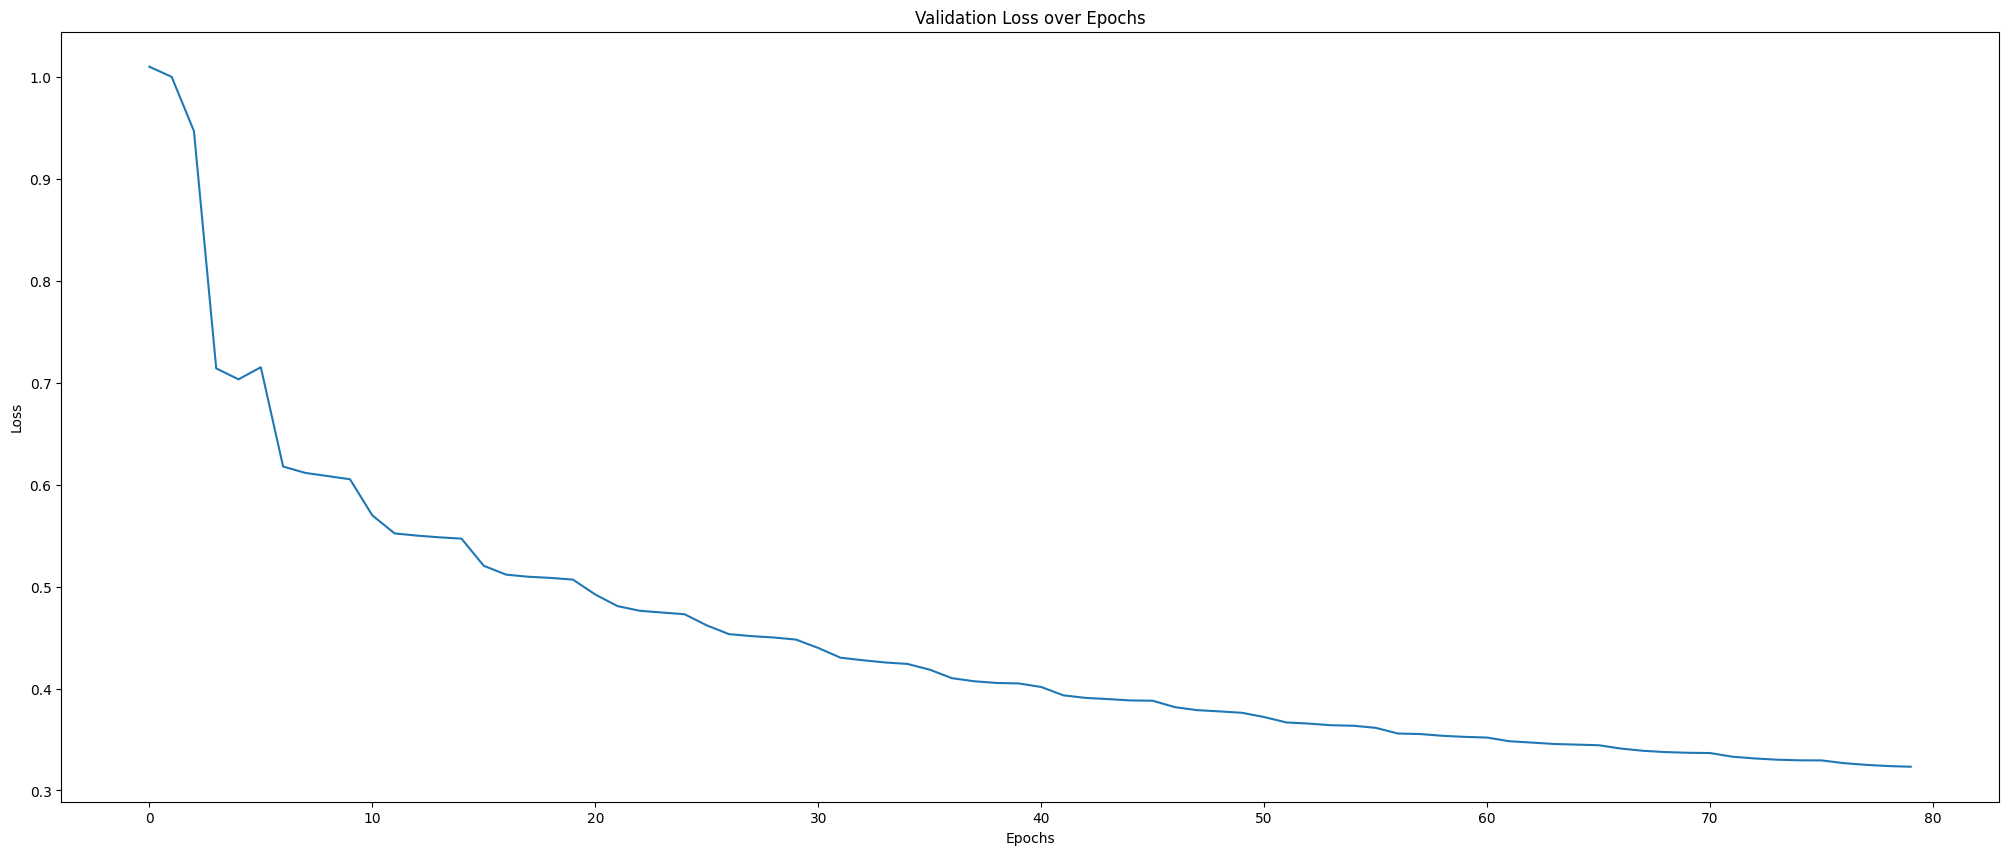

In [9]:
all_train_loss = np.load(f"{save_path}/all_train_losses.npy")
plt.plot(all_train_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation Loss over Epochs')
plt.gcf().set_size_inches(25, 10)
plt.show()

In [30]:
import tqdm
from model_utils import load_conv_model
import act_max_util as amu

IMG_WIDTH, IMG_HEIGHT = 32, 32
MAX_NEURONS = 64

steps = 100               # perform 100 iterations
alpha = torch.tensor(100) # learning rate (step size)
verbose = False           # print activation every step
L2_Decay = True           # enable L2 decay regularizer
Gaussian_Blur = False     # enable Gaussian regularizer
Norm_Crop = False         # enable norm regularizer
Contrib_Crop = False      # enable contribution regularizer

model_type = "dae"

rf_matrix = []

for epoch in range(1):
    data = torch.randn(3, IMG_WIDTH, IMG_HEIGHT)
    input = data.unsqueeze(0)
    
    input.requires_grad_(True)

    model_path = f"/home/david/paper_cifar_models/cnn/singular_step"
    ae = load_conv_model(model_path, model_type="dae", epoch=319, size_ls=size_ls)
    
    layer_name = 'bottle_neck'
    activation_dictionary = {}

    ae.encoder[11].register_forward_hook(amu.layer_hook(activation_dictionary, layer_name))

    loop_size = size_ls[epoch] if model_type == "dae" else MAX_NEURONS

    rf_ls = []
    for i in range(loop_size):
        output = amu.act_max(network=ae,
                        input=input,
                        layer_activation=activation_dictionary,
                        layer_name=layer_name,
                        unit=i,
                        steps=steps,
                        alpha=alpha,
                        verbose=verbose,
                        L2_Decay=L2_Decay,
                        Gaussian_Blur=Gaussian_Blur,
                        Norm_Crop=Norm_Crop,
                        Contrib_Crop=Contrib_Crop,
                        )
        rf_ls.append(output.detach().numpy())
    
    max_size = MAX_NEURONS

    # Pad the rf_ls list to max_size before converting to numpy array
    if loop_size < max_size:
        zero_rf = np.zeros_like(rf_ls[0])
        for _ in range(loop_size, max_size):
            rf_ls.append(zero_rf.copy())
    
    rf_ls = np.array(rf_ls).squeeze()
    rf_matrix.append(rf_ls)

64
/home/david/paper_cifar_models/cnn/singular_step/model_weights_epoch319.pth


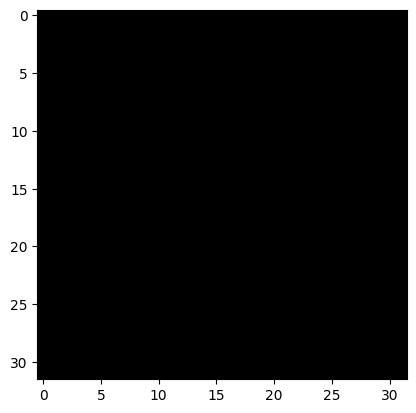

In [11]:
np.array(rf_matrix).squeeze()[0].shape


plt.imshow(np.transpose(np.array(rf_matrix).squeeze()[20], (1, 2, 0)), cmap='gray')

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7830755..2.0942786].


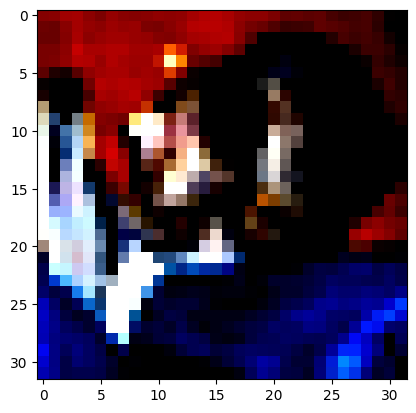

In [33]:
# 64
test_iter = iter(test_loader)
test_images, test_labels = next(test_iter)
test_image = test_images[0].unsqueeze(0)

plt.imshow(test_image.squeeze().permute(1, 2, 0).numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.85748565..0.8358597].


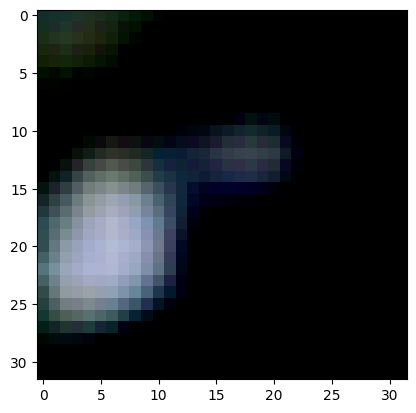

In [27]:
# 16
reconstructed_image = ae(test_image)[1].detach().squeeze().permute(1, 2, 0).numpy()
plt.imshow(reconstructed_image)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99879485..0.9999989].


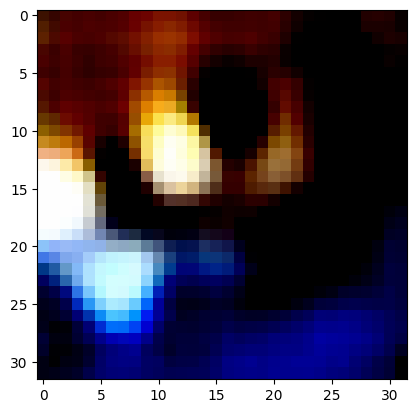

In [34]:
# get reconstruction of first image

reconstructed_image = ae(test_image)[1].detach().squeeze().permute(1, 2, 0).numpy()
plt.imshow(reconstructed_image)


/home/david/Documents/UNI_LOCAL/developing-autoencoders/solver.py:576: UserWarning: volatile was removed and now has no effect. Use `with torch.no_grad():` instead.
  data = Variable(data, volatile=True)
/home/david/.pyenv/versions/3.10.12/lib/python3.10/site-packages/torch/nn/_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  warnings.warn(warning.format(ret))
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6401843..1.9320949].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99998015..0.9999492].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..1.9654387].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.9999

====> Test set loss: 82595.5359


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8031324..2.115826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


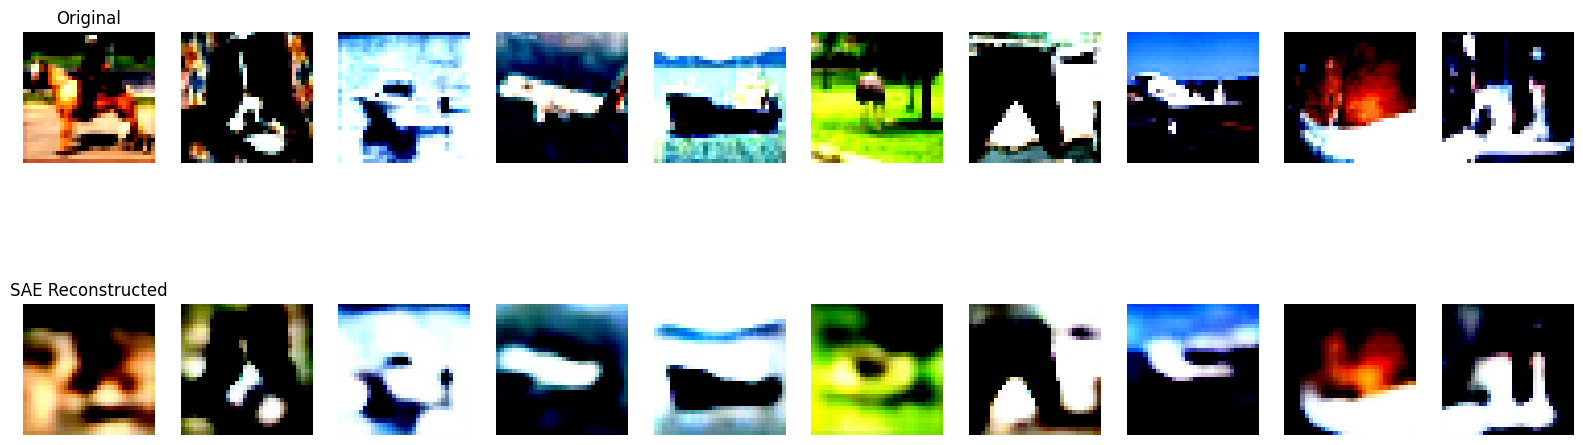

In [35]:
test_loss, decoded,test = test_conv(ae,test_loader)
fig = plt.figure(figsize=(20,10))
for i in range(10):
    plt.subplot(3,10,i+1)
    plt.imshow(np.transpose(test[i].numpy(),(1,2,0)))
    if i == 0:
        plt.title('Original')
    plt.axis('off')

    plt.subplot(3,10,i+11)
    plt.imshow(np.transpose(decoded[i].detach().numpy(),(1,2,0)))
    if i == 0:
        plt.title('SAE Reconstructed')
    plt.axis('off')

64
/home/david/paper_cifar_models/cnn/singular_step/model_weights_epoch319.pth
torch.Size([1, 3, 32, 32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-74.76883..41.61].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-26.942965..29.677536].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-32.34515..31.942476].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-44.309498..42.163258].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-50.291233..41.395412].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-32.734512..31.634373].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-33.950336..35.

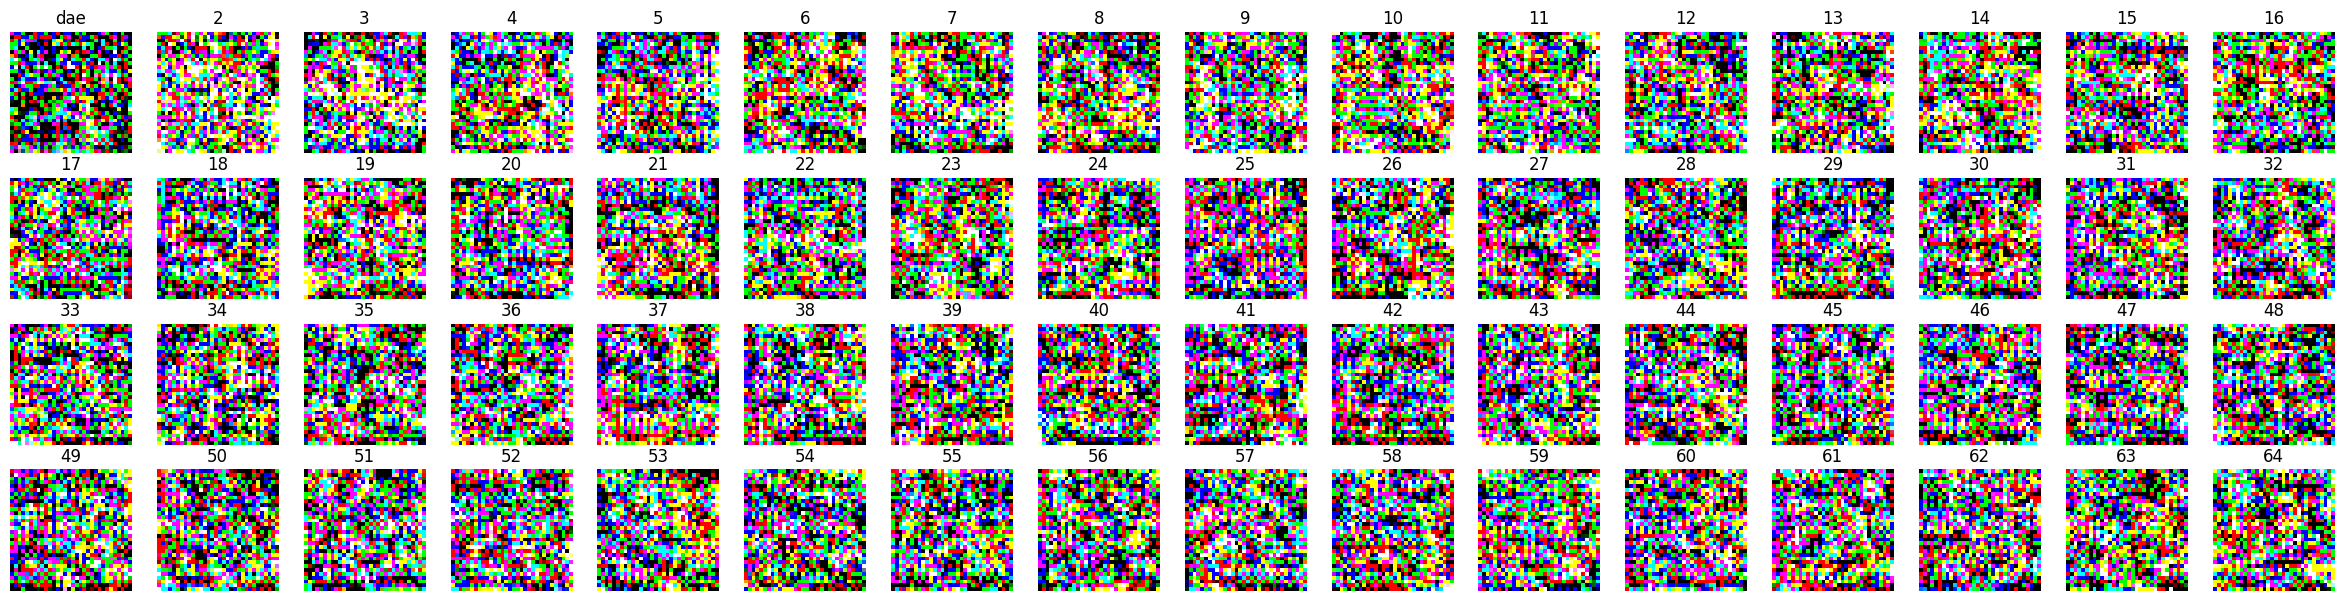

In [5]:
import tqdm
from model_utils import load_conv_model
import act_max_util as amu

model_path = f"/home/david/paper_cifar_models/cnn/singular_step"
ae = load_conv_model(model_path, model_type="dae", epoch=319, size_ls=size_ls)

IMG_WIDTH, IMG_HEIGHT = 32, 32
MAX_NEURONS = 64

steps = 100               # perform 100 iterations
alpha = torch.tensor(100) # learning rate (step size)
verbose = False           # print activation every step
L2_Decay = True           # enable L2 decay regularizer
Gaussian_Blur = False     # enable Gaussian regularizer
Norm_Crop = False         # enable norm regularizer
Contrib_Crop = False      # enable contribution regularizer


activation_dictionary = {}
layer_name = 'bottle_neck'
ae.encoder[11].register_forward_hook(amu.layer_hook(activation_dictionary, layer_name))

data = torch.randn(3,32, 32)
input = data.unsqueeze(0)
# input = data.view(data.size(0), -1)
input.requires_grad_(True)
print(input.shape)

dae_rf_ls = []
for i in range(64):
    output = amu.act_max(network=ae,
                    input=input,
                    layer_activation=activation_dictionary,
                    layer_name=layer_name,
                    unit=i,
                    steps=steps,
                    alpha=alpha,
                    verbose=verbose,
                    L2_Decay=L2_Decay,
                    Gaussian_Blur=Gaussian_Blur,
                    Norm_Crop=Norm_Crop,
                    Contrib_Crop=Contrib_Crop,
                    )
    dae_rf_ls.append(output.detach().numpy())

fig = plt.figure(figsize=(30,30))
for i in range(64):
    plt.subplot(16,16,i+1)
    if i == 0:
        plt.title('dae')
    else:
        plt.title(str(i+1))
    plt.axis('off')
    plt.xticks([])
    plt.yticks([])
    plt.imshow(np.transpose(dae_rf_ls[i].reshape(3,32,32), (1,2,0)))
plt.show()

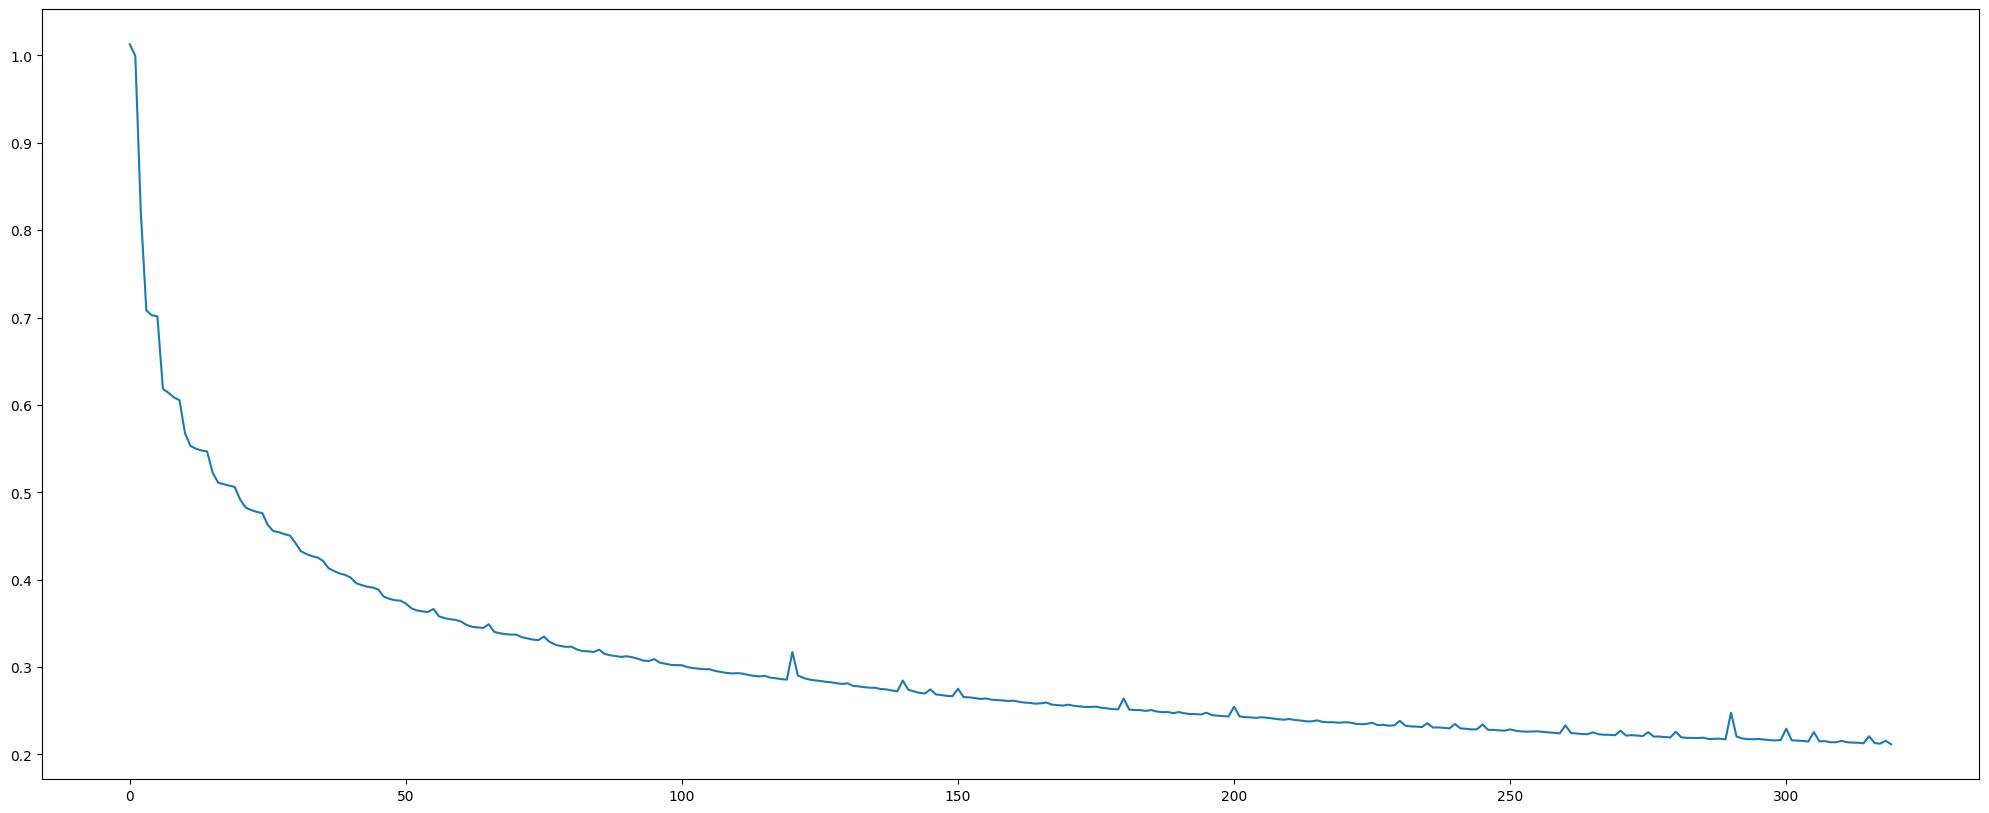

In [7]:
plt.plot(np.load(f"/home/david/paper_cifar_models/cnn/singular_step/all_train_losses.npy"))
plt.gcf().set_size_inches(25, 10)